# Fase 2: Entrenamiento del Modelo Base CNN


### Objetivo
Entrenar una Red Neuronal Convolucional 1D (CNN) supervisada para clasificar latidos ECG en 5 categorias AAMI, usando el dataset preprocesado de la Fase 1.

### Clases AAMI
| Clase | Codigo | Descripcion |
|-------|--------|-------------|
| Normal | N (0) | Latido sinusal normal |
| Supraventricular | S (1) | Latido supraventricular ectopico |
| Ventricular | V (2) | Latido ventricular ectopico |
| Fusion | F (3) | Latido de fusion |
| Desconocido | Q (4) | Latido no clasificable |

### Arquitectura
CNN 1D inspirada en Acharya et al. (2017): capas convolucionales con filtros crecientes, BatchNorm, Dropout, y capas densas de clasificacion.

In [ ]:
# ============================================================
# PASO 0: Instalar dependencias (ejecutar solo una vez)
# ============================================================
import sys
import subprocess

packages = ["torch", "wfdb", "tqdm", "scikit-learn", "seaborn"]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("Dependencias instaladas. Reinicia el kernel y corre desde la celda 3.")

Dependencias instaladas. Reinicia el kernel y corre desde la celda 3.


In [ ]:
# ============================================================
# PASO 1: Cargar y explorar el dataset preprocesado
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

DATA_PATH   = r"C:/Users/Marti/Desktop/PROYECT_ADAPT-ECG/data/processed"
DOCS_PATH   = r"C:/Users/Marti/Desktop/PROYECT_ADAPT-ECG/docs"
MODELS_PATH = r"C:/Users/Marti/Desktop/PROYECT_ADAPT-ECG/models"

X = np.load(DATA_PATH + "/X.npy")
y = np.load(DATA_PATH + "/y.npy")

AAMI_CLASSES = ["N", "S", "V", "F", "Q"]
AAMI_NAMES   = ["Normal", "Supraventricular", "Ventricular", "Fusion", "Desconocido"]
N_CLASSES    = len(AAMI_CLASSES)
BEAT_LEN     = X.shape[1]

print("Shape X : {}  ->  {:,} latidos x {} muestras".format(X.shape, X.shape[0], BEAT_LEN))
print("Shape y : {}".format(y.shape))
print("\nDistribucion de clases:")
counts = Counter(y.tolist())
for idx, (cls, name) in enumerate(zip(AAMI_CLASSES, AAMI_NAMES)):
    c = counts.get(idx, 0)
    pct = 100 * c / len(y)
    print("  {} - {:<20}: {:>7,} ({:.1f}%)".format(cls, name, c, pct))

Shape X : (6324, 71)  ->  6,324 latidos x 71 muestras
Shape y : (6324,)

Distribucion de clases:
  N - Normal              :   4,197 (66.4%)
  S - Supraventricular    :      36 (0.6%)
  V - Ventricular         :       5 (0.1%)
  F - Fusion              :       0 (0.0%)
  Q - Desconocido         :   2,086 (33.0%)


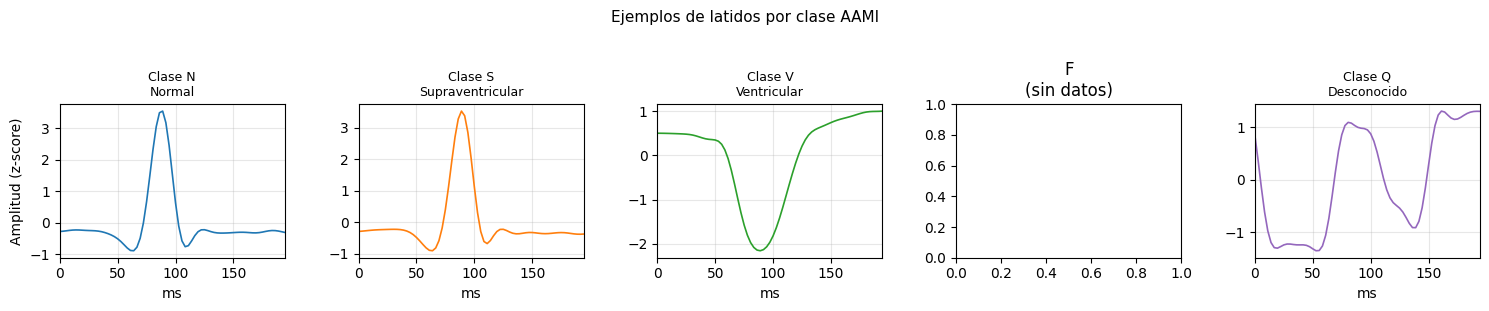

Figura guardada en: C:/Users/Marti/Desktop/PROYECT_ADAPT-ECG/docs/fase2_latidos_por_clase.png


In [ ]:
# ============================================================
# Visualizacion: un latido representativo por clase
# ============================================================
import os

os.makedirs(DOCS_PATH, exist_ok=True)

fig, axes = plt.subplots(1, N_CLASSES, figsize=(15, 3))
t = np.arange(BEAT_LEN) / 360 * 1000  # tiempo en ms

for idx, (cls, name) in enumerate(zip(AAMI_CLASSES, AAMI_NAMES)):
    mask = np.where(y == idx)[0]
    if len(mask) == 0:
        axes[idx].set_title("{}\n(sin datos)".format(cls))
        continue
    beat = X[mask[0]]
    axes[idx].plot(t, beat, color="C{}".format(idx), linewidth=1.2)
    axes[idx].set_title("Clase {}\n{}".format(cls, name), fontsize=9)
    axes[idx].set_xlabel("ms")
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlim([0, t[-1]])

axes[0].set_ylabel("Amplitud (z-score)")
plt.suptitle("Ejemplos de latidos por clase AAMI", fontsize=11, y=1.02)
plt.tight_layout()

fig_path = DOCS_PATH + "/fase2_latidos_por_clase.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada en: " + fig_path)

## Paso 2: Arquitectura CNN 1D
Red neuronal convolucional unidimensional para clasificacion de series temporales (senales ECG).

**Arquitectura:**
- 3 bloques convolucionales: Conv1d → BatchNorm → ReLU → MaxPool
- Filtros crecientes: 32 → 64 → 128
- Global Average Pooling para reduccion dimensional
- 2 capas densas con Dropout para regularizacion
- Salida: 5 neuronas con log_softmax (una por clase AAMI)

**Referencia:** Acharya et al. (2017), "Automated detection of arrhythmias using CNN", Inf. Sci., vol. 377.

In [ ]:
# ============================================================
# PASO 2: Definicion de la arquitectura CNN 1D
# ============================================================
import torch
import torch.nn as nn

class ECG_CNN(nn.Module):
    """
    Red Neuronal Convolucional 1D para clasificacion de arritmias ECG.

    Arquitectura de 3 bloques convolucionales con filtros crecientes,
    seguidos de capas densas con dropout para regularizacion.

    Parameters
    ----------
    n_classes : int
        Numero de clases de salida (5 para esquema AAMI).
    beat_len : int
        Longitud de cada latido en muestras.
    dropout : float
        Probabilidad de dropout en capas densas (default: 0.5).

    Input
    -----
    x : torch.Tensor, shape (batch, 1, beat_len)

    Output
    ------
    torch.Tensor, shape (batch, n_classes) — log-probabilidades.
    """

    def __init__(self, n_classes=5, beat_len=71, dropout=0.5):
        super().__init__()

        # Bloque 1: detecta caracteristicas locales de bajo nivel
        self.block1 = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
        )

        # Bloque 2: patrones de nivel intermedio (ondas P, QRS, T)
        self.block2 = nn.Sequential(
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
        )

        # Bloque 3: caracteristicas morfologicas de alto nivel
        self.block3 = nn.Sequential(
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )

        # Clasificador denso
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return nn.functional.log_softmax(x, dim=1)


# Verificar arquitectura
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo: {}".format(device))

model = ECG_CNN(n_classes=N_CLASSES, beat_len=BEAT_LEN).to(device)

total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Parametros totales    : {:,}".format(total_params))
print("Parametros entrenables: {:,}".format(train_params))

# Prueba de forma con un batch ficticio
dummy = torch.zeros(8, 1, BEAT_LEN).to(device)
out   = model(dummy)
print("Input shape : {}".format(dummy.shape))
print("Output shape: {}  ->  (batch=8, clases={})".format(out.shape, N_CLASSES))

Dispositivo: cpu
Parametros totales    : 44,229
Parametros entrenables: 44,229
Input shape : torch.Size([8, 1, 71])
Output shape: torch.Size([8, 5])  ->  (batch=8, clases=5)


In [ ]:
# ============================================================
# PASO 3: Dataset, DataLoader y configuracion de entrenamiento
# ============================================================
import torch
import numpy as np
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.utils.class_weight import compute_class_weight
import torch.nn as nn

# Recargar datos si no estan en memoria
if 'X' not in dir() or 'y' not in dir():
    DATA_PATH   = r"C:/Users/Marti/Desktop/PROYECT_ADAPT-ECG/data/processed"
    DOCS_PATH   = r"C:/Users/Marti/Desktop/PROYECT_ADAPT-ECG/docs"
    MODELS_PATH = r"C:/Users/Marti/Desktop/PROYECT_ADAPT-ECG/models"
    X = np.load(DATA_PATH + "/X.npy")
    y = np.load(DATA_PATH + "/y.npy")
    AAMI_CLASSES = ["N", "S", "V", "F", "Q"]
    N_CLASSES    = len(AAMI_CLASSES)
    BEAT_LEN     = X.shape[1]
    print("Datos recargados: X={}, y={}".format(X.shape, y.shape))

if 'model' not in dir() or 'device' not in dir():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    class ECG_CNN(nn.Module):
        def __init__(self, n_classes=5, dropout=0.5):
            super().__init__()
            self.block1 = nn.Sequential(nn.Conv1d(1,32,5,padding=2),nn.BatchNorm1d(32),nn.ReLU(),nn.MaxPool1d(2))
            self.block2 = nn.Sequential(nn.Conv1d(32,64,5,padding=2),nn.BatchNorm1d(64),nn.ReLU(),nn.MaxPool1d(2))
            self.block3 = nn.Sequential(nn.Conv1d(64,128,3,padding=1),nn.BatchNorm1d(128),nn.ReLU(),nn.AdaptiveAvgPool1d(1))
            self.classifier = nn.Sequential(nn.Flatten(),nn.Linear(128,64),nn.ReLU(),nn.Dropout(dropout),nn.Linear(64,n_classes))
        def forward(self, x):
            return nn.functional.log_softmax(self.classifier(self.block3(self.block2(self.block1(x)))), dim=1)
    model = ECG_CNN(n_classes=N_CLASSES).to(device)
    print("Modelo recreado en: {}".format(device))

BATCH_SIZE    = 64
LEARNING_RATE = 1e-3
EPOCHS        = 30
RANDOM_SEED   = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
y_tensor = torch.tensor(y, dtype=torch.long)

dataset = TensorDataset(X_tensor, y_tensor)
n_val   = int(len(dataset) * 0.2)
n_train = len(dataset) - n_val

train_ds, val_ds = random_split(
    dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(RANDOM_SEED)
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Train: {:,} | Val: {:,}".format(n_train, n_val))

# Pesos solo para clases presentes (F=0 en demo)
train_labels    = y[list(train_ds.indices)]
present_classes = np.unique(train_labels)
weights_present = compute_class_weight("balanced", classes=present_classes, y=train_labels)
class_weights   = np.ones(N_CLASSES, dtype=np.float64)
for idx, w in zip(present_classes, weights_present):
    class_weights[idx] = w

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Pesos de clase:")
for cls, w in zip(AAMI_CLASSES, class_weights):
    print("  {}: {:.3f}".format(cls, w))

criterion = nn.NLLLoss(weight=class_weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)


NameError: name 'X' is not defined

In [ ]:
# ============================================================
# PASO 4: Ciclo de entrenamiento con validacion
# ============================================================
import torch

def train_epoch(model, loader, criterion, optimizer, device):
    """Ejecuta una epoca de entrenamiento. Retorna loss y accuracy promedio."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model(X_batch)
        loss   = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(y_batch)
        preds       = output.argmax(dim=1)
        correct    += (preds == y_batch).sum().item()
        total      += len(y_batch)

    return total_loss / total, correct / total


def eval_epoch(model, loader, criterion, device):
    """Evalua el modelo en el conjunto de validacion. Retorna loss y accuracy."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            output     = model(X_batch)
            loss       = criterion(output, y_batch)
            total_loss += loss.item() * len(y_batch)
            preds       = output.argmax(dim=1)
            correct    += (preds == y_batch).sum().item()
            total      += len(y_batch)

    return total_loss / total, correct / total


# Historial para graficar curvas de aprendizaje
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

print("{:>5} | {:>10} | {:>9} | {:>8} | {:>7}".format(
    "Epoca", "Loss Train", "Acc Train", "Loss Val", "Acc Val"))
print("-" * 55)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    vl_loss, vl_acc = eval_epoch(model,  val_loader,   criterion,           device)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    print("{:>5} | {:>10.4f} | {:>8.2f}% | {:>8.4f} | {:>6.2f}%".format(
        epoch, tr_loss, tr_acc * 100, vl_loss, vl_acc * 100))

print("\nEntrenamiento completado.")

In [ ]:
# ============================================================
# Curvas de aprendizaje
# ============================================================
import matplotlib.pyplot as plt
import os

os.makedirs(DOCS_PATH, exist_ok=True)

epochs_range = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, history["train_loss"], label="Entrenamiento", color="steelblue")
ax1.plot(epochs_range, history["val_loss"],   label="Validacion",    color="tomato")
ax1.set_title("Funcion de Perdida (NLLLoss)")
ax1.set_xlabel("Epoca")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, [a * 100 for a in history["train_acc"]], label="Entrenamiento", color="steelblue")
ax2.plot(epochs_range, [a * 100 for a in history["val_acc"]],   label="Validacion",    color="tomato")
ax2.set_title("Precision (Accuracy)")
ax2.set_xlabel("Epoca")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Curvas de Aprendizaje — Modelo Base CNN", fontsize=12)
plt.tight_layout()

fig_path = DOCS_PATH + "/fase2_curvas_aprendizaje.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada en: " + fig_path)

In [ ]:
# ============================================================
# PASO 5: Evaluacion completa con metricas AAMI
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
import seaborn as sns

os.makedirs(DOCS_PATH, exist_ok=True)

# Obtener predicciones sobre el conjunto de validacion
model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        output  = model(X_batch)
        preds   = output.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Metricas globales
acc    = accuracy_score(all_labels, all_preds)
f1_mac = f1_score(all_labels, all_preds, average="macro",    zero_division=0)
f1_wtd = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

print("=" * 55)
print("  METRICAS DEL MODELO BASE (Conjunto de Validacion)")
print("=" * 55)
print("  Accuracy global    : {:.2f}%".format(acc * 100))
print("  F1-Score macro     : {:.4f}".format(f1_mac))
print("  F1-Score weighted  : {:.4f}".format(f1_wtd))
print()

# Reporte por clase
print(classification_report(
    all_labels, all_preds,
    target_names=AAMI_CLASSES,
    zero_division=0
))

# Matriz de confusion
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=AAMI_CLASSES,
    yticklabels=AAMI_CLASSES,
    ax=ax
)
ax.set_title("Matriz de Confusion — Modelo Base CNN", fontsize=12)
ax.set_xlabel("Clase predicha")
ax.set_ylabel("Clase real")
plt.tight_layout()

cm_path = DOCS_PATH + "/fase2_confusion_matrix.png"
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
print("Matriz de confusion guardada en: " + cm_path)

# Sensibilidad y especificidad por clase
print("\nSensibilidad y Especificidad por clase:")
for i, cls in enumerate(AAMI_CLASSES):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = cm.sum() - TP - FP - FN
    sens = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    spec = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    print("  {}: Sensibilidad={:.1f}%  Especificidad={:.1f}%".format(
        cls, sens * 100, spec * 100))

In [ ]:
# ============================================================
# PASO 6: Guardar modelo entrenado
# ============================================================
import os
import json
import torch

os.makedirs(MODELS_PATH, exist_ok=True)

# Guardar pesos del modelo
model_path = MODELS_PATH + "/ecg_cnn_base.pth"
torch.save(model.state_dict(), model_path)

# Guardar metadatos del modelo para reproducibilidad
metadata = {
    "model":        "ECG_CNN",
    "beat_len":     BEAT_LEN,
    "n_classes":    N_CLASSES,
    "aami_classes": AAMI_CLASSES,
    "epochs":       EPOCHS,
    "batch_size":   BATCH_SIZE,
    "lr":           LEARNING_RATE,
    "val_accuracy": round(float(acc), 4),
    "f1_macro":     round(float(f1_mac), 4),
    "f1_weighted":  round(float(f1_wtd), 4)
}

meta_path = MODELS_PATH + "/ecg_cnn_base_meta.json"
with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=2)

print("Modelo guardado en      : " + model_path)
print("Metadatos guardados en  : " + meta_path)
print("\nVal Accuracy : {:.2f}%".format(acc * 100))
print("F1 Macro     : {:.4f}".format(f1_mac))
print("\nPara cargar el modelo:")
print("  model.load_state_dict(torch.load('ecg_cnn_base.pth', map_location='cpu'))")